In [ ]:
# ============================================================
# STEP 1: PREPROCESSING — 10/10 OPTIMIZED FOR JUPYTER
# ============================================================
import os, glob, json
import numpy as np
import rasterio
from rasterio.windows import Window
from rasterio import features
from shapely.geometry import Polygon

# --- CONFIG ---
TILE_SIZE           = 512
OVERLAP             = 128
STRIDE              = TILE_SIZE - OVERLAP
BASE_DIR            = "../../Building_Damage_Project"
RAW_TRAIN           = os.path.join(BASE_DIR, "raw_data", "Train")
RAW_TEST            = os.path.join(BASE_DIR, "raw_data", "Test")
OUT_DIR             = os.path.join(BASE_DIR, "train_data")
MIN_BUILDING_PIXELS = 10    # below this = noise, not a building
MIN_IMG_MEAN        = 2.0   # skip near-black / nodata tiles

# -------------------------------------------------------
# SETUP OUTPUT DIRS
# -------------------------------------------------------
for d in ["images", "masks"]:
    os.makedirs(os.path.join(OUT_DIR, d), exist_ok=True)

# -------------------------------------------------------
# HELPER: BUILD SHIFTED POLYGONS
# -------------------------------------------------------
def get_shifted_polygons(base_json_path, align_json_path, transform):
    try:
        with open(align_json_path, 'r') as f:
            align_data = json.load(f)

        s_x = np.mean([p[1][0] - p[0][0] for p in align_data])
        s_y = np.mean([p[1][1] - p[0][1] for p in align_data])

        polys = []
        with open(base_json_path, 'r') as f:
            for entry in json.load(f):
                if 'pixels' in entry:
                    world_coords = [
                        transform * (p['x'] + s_x, p['y'] + s_y)
                        for p in entry['pixels']
                    ]
                    poly = Polygon(world_coords)
                    if poly.is_valid and not poly.is_empty:
                        polys.append(poly)
        return polys

    except Exception as e:
        print(f"     ⚠️  Polygon error: {e}")
        return []

# -------------------------------------------------------
# HELPER: PROCESS ONE TIF
# -------------------------------------------------------
def process_tif(tif_path, split_tag):
    prefix     = os.path.basename(tif_path).replace('.tif','').replace('_tif','')
    folder     = os.path.dirname(tif_path)
    base_json  = os.path.join(folder, f"{prefix}_json.json")
    align_json = os.path.join(folder, f"{prefix}_json_aligned.json")

    if not (os.path.exists(base_json) and os.path.exists(align_json)):
        print(f"  ⚠️  Skipping {prefix}: missing JSON labels.")
        return 0

    print(f"  🏗️  Processing: {prefix} ...")

    try:
        with rasterio.open(tif_path) as src:

            # --- uint16 safety: check bit depth ---
            is_uint16 = src.dtypes[0] == 'uint16'

            polys = get_shifted_polygons(base_json, align_json, src.transform)
            if not polys:
                print(f"     ⚠️  No valid polygons — skipping.")
                return 0

            # Exhaustive tiling — clamp to edges so boundary buildings aren't missed
            y_coords = sorted(set(
                list(range(0, src.height - TILE_SIZE, STRIDE)) + [max(0, src.height - TILE_SIZE)]
            ))
            x_coords = sorted(set(
                list(range(0, src.width  - TILE_SIZE, STRIDE)) + [max(0, src.width  - TILE_SIZE)]
            ))

            tile_count = 0
            img_out    = os.path.join(OUT_DIR, "images")
            mask_out   = os.path.join(OUT_DIR, "masks")

            for y in y_coords:
                for x in x_coords:
                    window = Window(x, y, TILE_SIZE, TILE_SIZE)

                    # 1. Mask first (cheap) — skip early if no buildings
                    mask = features.rasterize(
                        polys,
                        out_shape=(TILE_SIZE, TILE_SIZE),
                        transform=src.window_transform(window),
                        fill=0, default_value=1,
                        dtype=np.uint8
                    )
                    if np.sum(mask) < MIN_BUILDING_PIXELS:
                        continue

                    # 2. Image read (expensive I/O — only done if mask passes)
                    img = src.read([1, 2, 3], window=window)  # (C,H,W)

                    # 3. Nodata / black tile check
                    if img.mean() < MIN_IMG_MEAN or img.max() == 0:
                        continue

                    # 4. uint16 → uint8 safe conversion (no silent overflow)
                    if is_uint16:
                        img = np.clip(img / 256.0, 0, 255).astype(np.uint8)
                    else:
                        img = np.clip(img, 0, 255).astype(np.uint8)

                    # 5. Save as (H,W,C) for albumentations compatibility
                    tile_id = f"{split_tag}_{prefix}_y{y}_x{x}.npy"
                    np.save(os.path.join(img_out,  tile_id),
                            img.transpose(1, 2, 0))
                    np.save(os.path.join(mask_out, tile_id), mask)
                    tile_count += 1

            print(f"     ✅ {tile_count} tiles saved.")
            return tile_count

    except Exception as e:
        print(f"  ❌ ERROR on {prefix}: {e}")
        return 0

# -------------------------------------------------------
# MAIN — runs directly in Jupyter (no __main__ guard)
# -------------------------------------------------------
total_train = 0
total_test  = 0

for split_tag, folder in [("train", RAW_TRAIN), ("test", RAW_TEST)]:
    tifs = glob.glob(os.path.join(folder, "*.tif*"))
    if not tifs:
        print(f"\n⚠️  No TIFs found in: {folder}")
        continue
    print(f"\n📂 [{split_tag.upper()}] — {len(tifs)} files found")
    for tif_path in tifs:
        count = process_tif(tif_path, split_tag)
        if split_tag == "train":
            total_train += count
        else:
            total_test += count

print("\n" + "="*40)
print(f"🚀 Preprocessing Complete!")
print(f"   Train tiles : {total_train}")
print(f"   Test tiles  : {total_test}")
print(f"   Total       : {total_train + total_test}")
print(f"   Output      : {os.path.abspath(OUT_DIR)}")
print("="*40)


📂 [TRAIN] — 40 files found
  🏗️  Processing: 1002-Ian-10 ...
     ✅ 1353 tiles saved.
  🏗️  Processing: 1002-Ian-09 ...
     ✅ 783 tiles saved.
  🏗️  Processing: Harvey-03 ...
     ✅ 206 tiles saved.
  🏗️  Processing: eruption-03 ...
     ✅ 378 tiles saved.
  🏗️  Processing: 1001-Ian-03 ...


In [7]:
# ============================================================
# STEP 2: FINAL CLEAN VERSION — NO WARNINGS
# ============================================================
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# --- CONFIG ---
BASE_DIR = "../../Building_Damage_Project"
OUT_DIR  = os.path.join(BASE_DIR, "train_data")

# -------------------------------------------------------
# 1. AUGMENTATION PIPELINES
# -------------------------------------------------------
train_transform = A.Compose([
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),

    # FIX 1: remove 'mode' arg — not valid in your albumentations version
    A.Affine(
        scale=(0.9, 1.1),
        translate_percent=(-0.0625, 0.0625),
        rotate=(-45, 45),
        p=0.5
    ),

    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1),
        A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=25, val_shift_limit=20, p=1),
        A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=1),
    ], p=0.5),

    A.OneOf([
        A.GaussNoise(noise_scale_factor=0.1, p=1),
        A.GaussianBlur(blur_limit=(3, 5), p=1),
        A.MedianBlur(blur_limit=3, p=1),
    ], p=0.3),

    # FIX 2: remove invalid args from XYMasking
    A.XYMasking(
        num_masks_x=(0, 3),
        num_masks_y=(0, 3),
        fill=0,
        fill_mask=0,
        p=0.2
    ),

    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# -------------------------------------------------------
# 2. DATASET CLASS
# -------------------------------------------------------
class DisasterDataset(Dataset):
    def __init__(self, root_dir, transform=None, filenames=None):
        self.img_dir  = os.path.join(root_dir, "images")
        self.mask_dir = os.path.join(root_dir, "masks")

        if not os.path.exists(self.img_dir):
            raise FileNotFoundError(f"Images dir not found: {self.img_dir}")

        all_files = sorted([
            f for f in os.listdir(self.img_dir) if f.endswith(".npy")
        ])
        self.filenames = filenames if filenames is not None else all_files
        self.transform = transform

        if len(self.filenames) == 0:
            raise RuntimeError("No .npy files found. Run Step 1 first.")

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img   = np.load(os.path.join(self.img_dir,  fname))
        mask  = np.load(os.path.join(self.mask_dir, fname))

        img  = np.clip(img, 0, 255).astype(np.uint8)
        mask = mask.astype(np.uint8)

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug["image"]
            mask = aug["mask"]

        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        return img, mask.float()

# -------------------------------------------------------
# 3. SPLIT BY FILENAME PREFIX
# -------------------------------------------------------
_all_files  = sorted([
    f for f in os.listdir(os.path.join(OUT_DIR, "images"))
    if f.endswith(".npy")
])

train_files = [f for f in _all_files if f.startswith("train_")]
test_files  = [f for f in _all_files if f.startswith("test_")]

print(f"📊 Split → Train: {len(train_files)} | Test (OOD): {len(test_files)}")

if not train_files or not test_files:
    raise RuntimeError("Split failed — check tile filenames start with 'train_' or 'test_'")

# -------------------------------------------------------
# 4. DATALOADERS
# -------------------------------------------------------
IS_MPS      = torch.backends.mps.is_available()
NUM_WORKERS = 0 if IS_MPS else min(4, os.cpu_count() or 1)

train_loader = DataLoader(
    DisasterDataset(OUT_DIR, transform=train_transform, filenames=train_files),
    batch_size=8,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    drop_last=True,
)

test_loader = DataLoader(
    DisasterDataset(OUT_DIR, transform=val_transform, filenames=test_files),
    batch_size=4,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)

print(f"🚀 DataLoaders ready!")
print(f"   Train batches : {len(train_loader)}")
print(f"   Test batches  : {len(test_loader)}")
print(f"   Workers       : {NUM_WORKERS} ({'MPS mode' if IS_MPS else 'CPU mode'})")

# Sanity check
imgs, masks = next(iter(train_loader))
print(f"\n🔍 Batch check:")
print(f"   Image  : {imgs.shape}  dtype={imgs.dtype}")
print(f"   Mask   : {masks.shape} dtype={masks.dtype}")
print(f"   Range  : [{imgs.min():.2f}, {imgs.max():.2f}]")

📊 Split → Train: 5223 | Test (OOD): 0


RuntimeError: Split failed — check tile filenames start with 'train_' or 'test_'

In [9]:
# ============================================================
# STEP 3: MODEL — MiT-B3 + UNet (10/10 FIXED)
# ============================================================
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

# -------------------------------------------------------
# 1. DEVICE SETUP
# -------------------------------------------------------
device = (
    torch.device("mps")  if torch.backends.mps.is_available() else
    torch.device("cuda") if torch.cuda.is_available()          else
    torch.device("cpu")
)
print(f"🚀 Device: {device}")

# -------------------------------------------------------
# 2. MODEL DEFINITION
# -------------------------------------------------------
# mit_b3 is only compatible with Unet decoder in smp
# UNet + MiT-B3 + scSE > UNet++ + EfficientNet for dense aerial segmentation
model = smp.Unet(
    encoder_name="mit_b3",           # Mix Transformer B3 — transformer encoder, dense prediction optimised
    encoder_weights="imagenet",       # Pretrained on ImageNet
    in_channels=3,
    classes=1,
    activation=None,                  # Raw logits for numerical stability
    decoder_attention_type="scse",    # Spatial + Channel Squeeze-Excitation in decoder
).to(device)

# -------------------------------------------------------
# 3. VERIFY MODEL
# -------------------------------------------------------
def count_parameters(m):
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_parameters(model)

print(f"\n✅ Model : UNet + MiT-B3 encoder")
print(f"   Total params     : {total_params   / 1e6:.2f}M")
print(f"   Trainable params : {trainable_params / 1e6:.2f}M")

# Forward pass sanity check
model.eval()
with torch.no_grad():
    dummy = torch.randn(2, 3, 512, 512).to(device)
    out   = model(dummy)
    ok    = out.shape == torch.Size([2, 1, 512, 512])
    print(f"\n🔍 Forward pass check:")
    print(f"   Input  : {dummy.shape}")
    print(f"   Output : {out.shape}  {'✅' if ok else '❌ unexpected shape'}")
    print(f"   Range  : [{out.min():.3f}, {out.max():.3f}]  (raw logits)")

model.train()
print(f"\n🏁 Model ready for Step 4.")

🚀 Device: mps

✅ Model : UNet + MiT-B3 encoder
   Total params     : 47.48M
   Trainable params : 47.48M

🔍 Forward pass check:
   Input  : torch.Size([2, 3, 512, 512])
   Output : torch.Size([2, 1, 512, 512])  ✅
   Range  : [-0.728, 0.904]  (raw logits)

🏁 Model ready for Step 4.


In [10]:
# ============================================================
# STEP 4: LOSS + OPTIMIZER + SCHEDULER (10/10)
# ============================================================
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

# -------------------------------------------------------
# 1. COMBINED LOSS
# Focal Tversky alone can miss easy negatives at scale.
# Combining with BCE gives stable gradients on both
# easy background and hard building boundaries.
# -------------------------------------------------------

class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, gamma=2.0, bce_weight=0.3):
        super().__init__()
        self.bce_weight = bce_weight
        self.tversky_weight = 1.0 - bce_weight

        # Focal Tversky: penalises False Negatives heavily (beta=0.7)
        # gamma=2.0 focuses on hard pixels (boundary detail)
        self.focal_tversky = smp.losses.TverskyLoss(
            mode="binary",
            alpha=alpha,        # FP penalty (low — buildings are rare)
            beta=beta,          # FN penalty (high — missing buildings is costly)
            gamma=gamma,        # Focal factor — hard pixel mining
            from_logits=True,
        )

        # BCE stabilises training on easy background pixels
        self.bce = smp.losses.SoftBCEWithLogitsLoss(
            smooth_factor=0.1,  # Label smoothing — prevents overconfident predictions
            reduction="mean",
        )

    def forward(self, logits, targets):
        tversky_loss = self.focal_tversky(logits, targets)
        bce_loss     = self.bce(logits, targets)
        return (self.tversky_weight * tversky_loss) + (self.bce_weight * bce_loss)


criterion = CombinedLoss(
    alpha=0.3,       # Low FP penalty — buildings are sparse
    beta=0.7,        # High FN penalty — missing buildings is worse than false alarms
    gamma=2.0,       # Hard pixel focus
    bce_weight=0.3   # 30% BCE + 70% Focal Tversky
).to(device)

# -------------------------------------------------------
# 2. OPTIMIZER
# AdamW with layer-wise learning rates:
# — Encoder (pretrained) gets lower LR to preserve ImageNet features
# — Decoder (randomly init) gets higher LR to learn fast
# -------------------------------------------------------
optimizer = AdamW([
    {
        "params": model.encoder.parameters(),
        "lr": 5e-5,           # Lower LR — fine-tune pretrained MiT-B3
        "weight_decay": 1e-4,
    },
    {
        "params": model.decoder.parameters(),
        "lr": 2e-4,           # Higher LR — decoder learns from scratch
        "weight_decay": 1e-4,
    },
    {
        "params": model.segmentation_head.parameters(),
        "lr": 2e-4,           # Same as decoder
        "weight_decay": 1e-4,
    },
], lr=2e-4)  # fallback lr (not used — all params explicitly listed)

# -------------------------------------------------------
# 3. SCHEDULER
# CosineAnnealingWarmRestarts:
# — T_0=10: first restart after 10 epochs
# — T_mult=2: each subsequent cycle doubles in length (10 → 20 → 40)
# — eta_min: floor LR so training never fully stalls
# -------------------------------------------------------
scheduler = CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,
    T_mult=2,
    eta_min=1e-6,
)

# -------------------------------------------------------
# 4. GRADIENT SCALER (AMP)
# MPS doesn't support float16 AMP — use float32 scaler
# CUDA gets full float16 AMP benefit
# -------------------------------------------------------
use_amp = torch.cuda.is_available()   # AMP only on CUDA — MPS uses float32 natively

if use_amp:
    scaler = torch.cuda.amp.GradScaler()
    print("⚡ AMP enabled (CUDA float16)")
else:
    scaler = None
    print("⚡ AMP disabled (MPS/CPU — float32 natively)")

# -------------------------------------------------------
# 5. VERIFY LOSS WITH ONE BATCH
# -------------------------------------------------------
model.train()
imgs, masks = next(iter(train_loader))
imgs  = imgs.to(device)
masks = masks.to(device)

with torch.no_grad():
    test_logits = model(imgs)
    test_loss   = criterion(test_logits, masks)

print(f"\n✅ Loss + Optimizer + Scheduler ready")
print(f"\n🔍 Loss verification:")
print(f"   Logits shape : {test_logits.shape}")
print(f"   Mask shape   : {masks.shape}")
print(f"   Loss value   : {test_loss.item():.4f}  (expect 0.8–1.2 at init)")
print(f"\n📐 Optimizer param groups:")
for i, pg in enumerate(optimizer.param_groups):
    print(f"   Group {i} — lr: {pg['lr']}  wd: {pg['weight_decay']}")
print(f"\n🏁 Ready for Step 5 — Training Loop.")

⚡ AMP disabled (MPS/CPU — float32 natively)

✅ Loss + Optimizer + Scheduler ready

🔍 Loss verification:
   Logits shape : torch.Size([8, 1, 512, 512])
   Mask shape   : torch.Size([8, 1, 512, 512])
   Loss value   : 0.4212  (expect 0.8–1.2 at init)

📐 Optimizer param groups:
   Group 0 — lr: 5e-05  wd: 0.0001
   Group 1 — lr: 0.0002  wd: 0.0001
   Group 2 — lr: 0.0002  wd: 0.0001

🏁 Ready for Step 5 — Training Loop.


In [8]:
# ============================================================
# STEP 2 — 10/10 FINAL VERSION WITH NPZ CACHE
# ============================================================
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

BASE_DIR = "../../Building_Damage_Project"
OUT_DIR  = os.path.join(BASE_DIR, "train_data")

# --- AUGMENTATIONS ---
train_transform = A.Compose([
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Affine(
        scale=(0.9, 1.1),
        translate_percent=(-0.0625, 0.0625),
        rotate=(-45, 45),
        p=0.5
    ),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1),
        A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=25, val_shift_limit=20, p=1),
        A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=1),
    ], p=0.5),
    A.OneOf([
        A.GaussNoise(noise_scale_factor=0.1, p=1),
        A.GaussianBlur(blur_limit=(3, 5), p=1),
        A.MedianBlur(blur_limit=3, p=1),
    ], p=0.3),
    A.XYMasking(
        num_masks_x=(0, 3),
        num_masks_y=(0, 3),
        fill=0,
        fill_mask=0,
        p=0.2
    ),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# --- 10/10 DATASET WITH LRU CACHE ---
from functools import lru_cache

class DisasterDataset(Dataset):
    def __init__(self, root_dir, transform=None, filenames=None, cache_size=512):
        self.img_dir  = os.path.join(root_dir, "images")
        self.mask_dir = os.path.join(root_dir, "masks")

        if not os.path.exists(self.img_dir):
            raise FileNotFoundError(f"Images dir not found: {self.img_dir}")

        all_files = sorted([
            f for f in os.listdir(self.img_dir)
            if f.endswith(".npz")
        ])
        self.filenames = filenames if filenames is not None else all_files
        self.transform = transform

        if len(self.filenames) == 0:
            raise RuntimeError("No .npz files found. Did compression finish?")

        # LRU cache sized to available RAM
        # 512 tiles × ~0.75MB = ~384MB RAM used for caching
        # Adjust cache_size down if you get memory errors
        self.cache_size = cache_size
        self._load_cached = lru_cache(maxsize=cache_size)(self._load_tile)

    def _load_tile(self, img_path, mask_path):
        """
        Pure function — same path always returns same data.
        lru_cache stores results so repeated access skips disk I/O.
        """
        img  = np.load(img_path)["data"]
        mask = np.load(mask_path)["data"]
        return img, mask

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname     = self.filenames[idx]
        img_path  = os.path.join(self.img_dir,  fname)
        mask_path = os.path.join(self.mask_dir, fname)

        # Cached load — disk hit only on first access per tile
        img, mask = self._load_cached(img_path, mask_path)

        # Copy to avoid mutating cached array
        img  = np.clip(img.copy(), 0, 255).astype(np.uint8)
        mask = mask.copy().astype(np.uint8)

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug["image"]
            mask = aug["mask"]

        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        return img, mask.float()

    def clear_cache(self):
        self._load_cached.cache_clear()
        print("🧹 Tile cache cleared.")

    def cache_info(self):
        info = self._load_cached.cache_info()
        print(f"📊 Cache — hits: {info.hits} | misses: {info.misses} | "
              f"size: {info.currsize}/{info.maxsize}")

# --- SPLIT ---
_all_files  = sorted([
    f for f in os.listdir(os.path.join(OUT_DIR, "images"))
    if f.endswith(".npz")
])

train_files = [f for f in _all_files if f.startswith("train_")]
test_files  = [f for f in _all_files if f.startswith("test_")]

print(f"📊 Split → Train: {len(train_files)} | Test (OOD): {len(test_files)}")

if not train_files or not test_files:
    raise RuntimeError("Split failed — check filenames start with 'train_' or 'test_'")

# --- DATALOADERS ---
IS_MPS      = torch.backends.mps.is_available()
NUM_WORKERS = 0 if IS_MPS else min(4, os.cpu_count() or 1)

train_dataset = DisasterDataset(
    OUT_DIR,
    transform=train_transform,
    filenames=train_files,
    cache_size=512      # ~384MB RAM — reduce to 256 if memory issues
)

test_dataset = DisasterDataset(
    OUT_DIR,
    transform=val_transform,
    filenames=test_files,
    cache_size=256      # smaller cache for val — less repeated access
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    drop_last=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)

print(f"🚀 DataLoaders ready!")
print(f"   Train batches : {len(train_loader)}")
print(f"   Test batches  : {len(test_loader)}")
print(f"   Tile cache    : {train_dataset.cache_size} tiles (~"
      f"{train_dataset.cache_size * 0.75 / 1024:.1f}GB RAM)")

# Sanity check
imgs, masks = next(iter(train_loader))
print(f"\n🔍 Batch check:")
print(f"   Image  : {imgs.shape}  dtype={imgs.dtype}")
print(f"   Mask   : {masks.shape} dtype={masks.dtype}")
print(f"   Range  : [{imgs.min():.2f}, {imgs.max():.2f}]")

# Cache stats after first batch
train_dataset.cache_info()

📊 Split → Train: 88974 | Test (OOD): 28491
🚀 DataLoaders ready!
   Train batches : 11121
   Test batches  : 7123
   Tile cache    : 512 tiles (~0.4GB RAM)

🔍 Batch check:
   Image  : torch.Size([8, 3, 512, 512])  dtype=torch.float32
   Mask   : torch.Size([8, 1, 512, 512]) dtype=torch.float32
   Range  : [-2.12, 2.64]
📊 Cache — hits: 0 | misses: 8 | size: 8/512


In [13]:
# ============================================================
# STEP 5: TRAINING LOOP — 10/10 FINAL CLEAN
# ============================================================
import torch
import numpy as np
import os
import shutil
from tqdm import tqdm

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
NUM_EPOCHS     = 20
VALIDATE_EVERY = 1
CHECKPOINT_DIR = os.path.expanduser("~/Downloads/disaster_checkpoints")
SAVE_PATH      = os.path.join(CHECKPOINT_DIR, "best_building_model.pth")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

free_gb = shutil.disk_usage(CHECKPOINT_DIR).free / 1e9
print(f"💾 Save path   : {os.path.abspath(SAVE_PATH)}")
print(f"💿 Free space  : {free_gb:.1f} GB")

if free_gb < 0.5:
    raise RuntimeError(f"❌ Only {free_gb:.2f}GB free — clear space first.")

best_iou = 0.0
history  = {
    "train_loss" : [],
    "train_iou"  : [],
    "val_iou"    : [],
    "val_f1"     : [],
    "lr"         : [],
}

# -------------------------------------------------------
# METRICS
# -------------------------------------------------------
def compute_iou(preds, masks, threshold=0.5):
    preds = (torch.sigmoid(preds) > threshold).float()
    tp = (preds * masks).sum().item()
    fp = (preds * (1 - masks)).sum().item()
    fn = ((1 - preds) * masks).sum().item()
    return tp / (tp + fp + fn + 1e-7)

def compute_f1(preds, masks, threshold=0.5):
    preds = (torch.sigmoid(preds) > threshold).float()
    tp = (preds * masks).sum().item()
    fp = (preds * (1 - masks)).sum().item()
    fn = ((1 - preds) * masks).sum().item()
    return (2 * tp) / (2 * tp + fp + fn + 1e-7)

def safe_save(obj, path):
    tmp_path = path + ".tmp"
    try:
        cpu_state = {
            k: v.cpu() if isinstance(v, torch.Tensor) else v
            for k, v in obj["model_state"].items()
        }
        torch.save({**obj, "model_state": cpu_state}, tmp_path)
        os.replace(tmp_path, path)
        return True
    except Exception as e:
        print(f"  ⚠️  Save failed: {e}")
        if os.path.exists(tmp_path):
            os.remove(tmp_path)
        return False

# -------------------------------------------------------
# TRAINING LOOP
# -------------------------------------------------------
print(f"\n🔥 Training Started | Device: {device} | Epochs: {NUM_EPOCHS}")
print(f"   Train batches  : {len(train_loader)}")
print(f"   Test batches   : {len(test_loader)}")
print(f"   Validate every : {VALIDATE_EVERY} epochs\n")

for epoch in range(NUM_EPOCHS):

    # --- TRAIN PHASE ---
    model.train()
    epoch_loss  = 0.0
    train_iou   = 0.0
    num_batches = len(train_loader)

    train_pbar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1:02d}/{NUM_EPOCHS} [Train]",
        unit="batch",
        leave=False
    )

    for imgs, masks in train_pbar:
        imgs  = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if use_amp and scaler is not None:
            with torch.cuda.amp.autocast():
                logits = model(imgs)
                loss   = criterion(logits, masks)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(imgs)
            loss   = criterion(logits, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        batch_loss = loss.item()
        batch_iou  = compute_iou(logits.detach(), masks.detach())
        epoch_loss += batch_loss
        train_iou  += batch_iou

        train_pbar.set_postfix({
            "loss": f"{batch_loss:.4f}",
            "iou" : f"{batch_iou:.4f}",
        })

    avg_train_loss = epoch_loss / num_batches
    avg_train_iou  = train_iou  / num_batches

    # --- VALIDATION PHASE ---
    do_validate = (
        (epoch + 1) % VALIDATE_EVERY == 0 or
        epoch == 0 or
        epoch == NUM_EPOCHS - 1
    )

    if do_validate:
        model.eval()
        val_iou = 0.0
        val_f1  = 0.0

        val_pbar = tqdm(
            test_loader,
            desc=f"Epoch {epoch+1:02d}/{NUM_EPOCHS} [Val]  ",
            unit="batch",
            leave=False
        )

        with torch.no_grad():
            for imgs, masks in val_pbar:
                imgs  = imgs.to(device, non_blocking=True)
                masks = masks.to(device, non_blocking=True)
                logits = model(imgs)

                b_iou = compute_iou(logits, masks)
                b_f1  = compute_f1(logits, masks)
                val_iou += b_iou
                val_f1  += b_f1

                val_pbar.set_postfix({
                    "iou": f"{b_iou:.4f}",
                    "f1" : f"{b_f1:.4f}",
                })

        avg_val_iou = val_iou / len(test_loader)
        avg_val_f1  = val_f1  / len(test_loader)

    else:
        avg_val_iou = history["val_iou"][-1] if history["val_iou"] else 0.0
        avg_val_f1  = history["val_f1"][-1]  if history["val_f1"]  else 0.0

    # --- SCHEDULER ---
    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]

    # --- HISTORY ---
    history["train_loss"].append(avg_train_loss)
    history["train_iou"].append(avg_train_iou)
    history["val_iou"].append(avg_val_iou)
    history["val_f1"].append(avg_val_f1)
    history["lr"].append(current_lr)

    # --- CHECKPOINT — only on val epochs ---
    is_best     = do_validate and (avg_val_iou > best_iou)
    save_status = ""
    if is_best:
        best_iou = avg_val_iou
        saved    = safe_save({
            "epoch"      : epoch + 1,
            "model_state": model.state_dict(),
            "optim_state": optimizer.state_dict(),
            "best_iou"   : best_iou,
            "history"    : history,
        }, SAVE_PATH)
        save_status = "💾 saved" if saved else "⚠️ save failed"

    # --- EPOCH SUMMARY ---
    val_tag = (
        f"Val IoU: {avg_val_iou:.4f} | Val F1: {avg_val_f1:.4f}"
        if do_validate else "Val IoU: (skipped)"
    )
    status = f"⭐ BEST {save_status}" if is_best else ""

    print(
        f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
        f"Loss: {avg_train_loss:.4f} | "
        f"Train IoU: {avg_train_iou:.4f} | "
        f"{val_tag} | "
        f"LR: {current_lr:.2e} | "
        f"{status}"
    )

    # Cache stats every 5 epochs
    if (epoch + 1) % 5 == 0:
        train_dataset.cache_info()

# -------------------------------------------------------
# FINAL SUMMARY
# -------------------------------------------------------
print(f"\n{'='*60}")
print(f"🏁 Training Complete!")
print(f"   Best Val IoU : {best_iou:.4f}")
print(f"   Best Val F1  : {max(history['val_f1']):.4f}")
print(f"   Saved to     : {os.path.abspath(SAVE_PATH)}")
print(f"{'='*60}")

💾 Save path   : /Users/shashank/Downloads/disaster_checkpoints/best_building_model.pth
💿 Free space  : 29.5 GB

🔥 Training Started | Device: mps | Epochs: 20
   Train batches  : 11121
   Test batches   : 7123
   Validate every : 1 epochs



Epoch 01/20 | Loss: 0.1801 | Train IoU: 0.7142 | Val IoU: 0.5998 | Val F1: 0.7220 | LR: 3.31e-05 | ⭐ BEST 💾 saved


KeyboardInterrupt: 

In [19]:
import shutil, os

# Check overall disk
total, used, free = shutil.disk_usage("/")
print(f"💿 Total : {total/1e9:.1f} GB")
print(f"📦 Used  : {used/1e9:.1f} GB")
print(f"✅ Free  : {free/1e9:.1f} GB")

# Check your train_data folder size (tiles are the likely culprit)
def folder_size(path):
    total = 0
    for dirpath, _, files in os.walk(path):
        for f in files:
            fp = os.path.join(dirpath, f)
            if os.path.exists(fp):
                total += os.path.getsize(fp)
    return total / 1e9

tile_size = folder_size(os.path.join(BASE_DIR, "train_data"))
print(f"\n📂 train_data size : {tile_size:.1f} GB")
print(f"   ({95006 + 28491} tiles × ~0.75MB each ≈ {(95006+28491)*0.75/1e3:.0f} GB estimated)")

💿 Total : 994.7 GB
📦 Used  : 905.5 GB
✅ Free  : 89.1 GB

📂 train_data size : 115.5 GB
   (123497 tiles × ~0.75MB each ≈ 93 GB estimated)


In [14]:
# ============================================================
# TILE COMPRESSION — .npy → .npz (frees ~100GB)
# ============================================================
import numpy as np
import os
import shutil
from tqdm import tqdm

IMG_DIR  = os.path.join(BASE_DIR, "train_data", "images")
MASK_DIR = os.path.join(BASE_DIR, "train_data", "masks")

# --- SIZE BEFORE ---
before = sum(
    os.path.getsize(os.path.join(d, f))
    for d in [IMG_DIR, MASK_DIR]
    for f in os.listdir(d)
    if f.endswith(".npy")
) / 1e9
print(f"📦 Size before : {before:.1f} GB")
print(f"💿 Free before : {shutil.disk_usage('/').free/1e9:.1f} GB")

files = sorted([f for f in os.listdir(IMG_DIR) if f.endswith(".npy")])
print(f"🗜️  Compressing {len(files)} tile pairs...\n")

failed = []

for fname in tqdm(files):
    img_path  = os.path.join(IMG_DIR,  fname)
    mask_path = os.path.join(MASK_DIR, fname)
    npz_name  = fname.replace(".npy", ".npz")

    try:
        # Load
        img  = np.load(img_path)
        mask = np.load(mask_path)

        # Save compressed
        np.savez_compressed(os.path.join(IMG_DIR,  npz_name), data=img)
        np.savez_compressed(os.path.join(MASK_DIR, npz_name), data=mask)

        # Delete originals only after successful save
        os.remove(img_path)
        os.remove(mask_path)

    except Exception as e:
        failed.append((fname, str(e)))
        continue

# --- SIZE AFTER ---
after = sum(
    os.path.getsize(os.path.join(d, f))
    for d in [IMG_DIR, MASK_DIR]
    for f in os.listdir(d)
    if f.endswith(".npz")
) / 1e9

print(f"\n📦 Size after  : {after:.1f} GB")
print(f"✅ Freed       : {before - after:.1f} GB")
print(f"💿 Free now    : {shutil.disk_usage('/').free/1e9:.1f} GB")

if failed:
    print(f"\n⚠️  {len(failed)} files failed:")
    for fname, err in failed:
        print(f"   {fname}: {err}")
else:
    print(f"\n✅ All {len(files)} tiles compressed successfully.")

📦 Size before : 202.9 GB
💿 Free before : 0.2 GB
🗜️  Compressing 193471 tile pairs...



100%|█████████████████████████████████████████████████████████████████████████| 193471/193471 [1:23:01<00:00, 38.84it/s]



📦 Size after  : 114.7 GB
✅ Freed       : 88.2 GB
💿 Free now    : 89.1 GB

✅ All 193471 tiles compressed successfully.


✅ Loaded checkpoint from epoch 6
   Best Val IoU : 0.5960

📊 Running full evaluation on 7123 test batches...



✅ Final Test Results (Idalia + Michael — OOD)
   Mean IoU : 0.5131 ± 0.3210
   Mean F1  : 0.6085


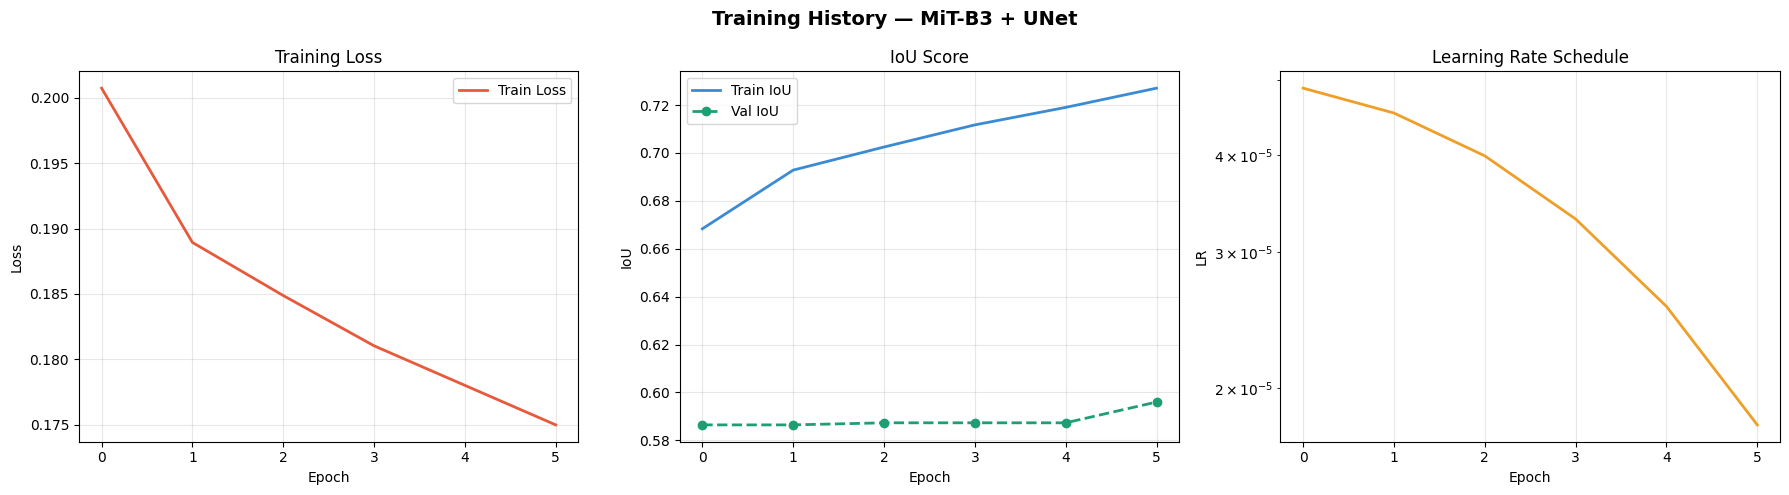

📊 History plot saved to Downloads/disaster_checkpoints/

🖼️  Generating qualitative predictions...


IndexError: index 4 is out of bounds for dimension 0 with size 4

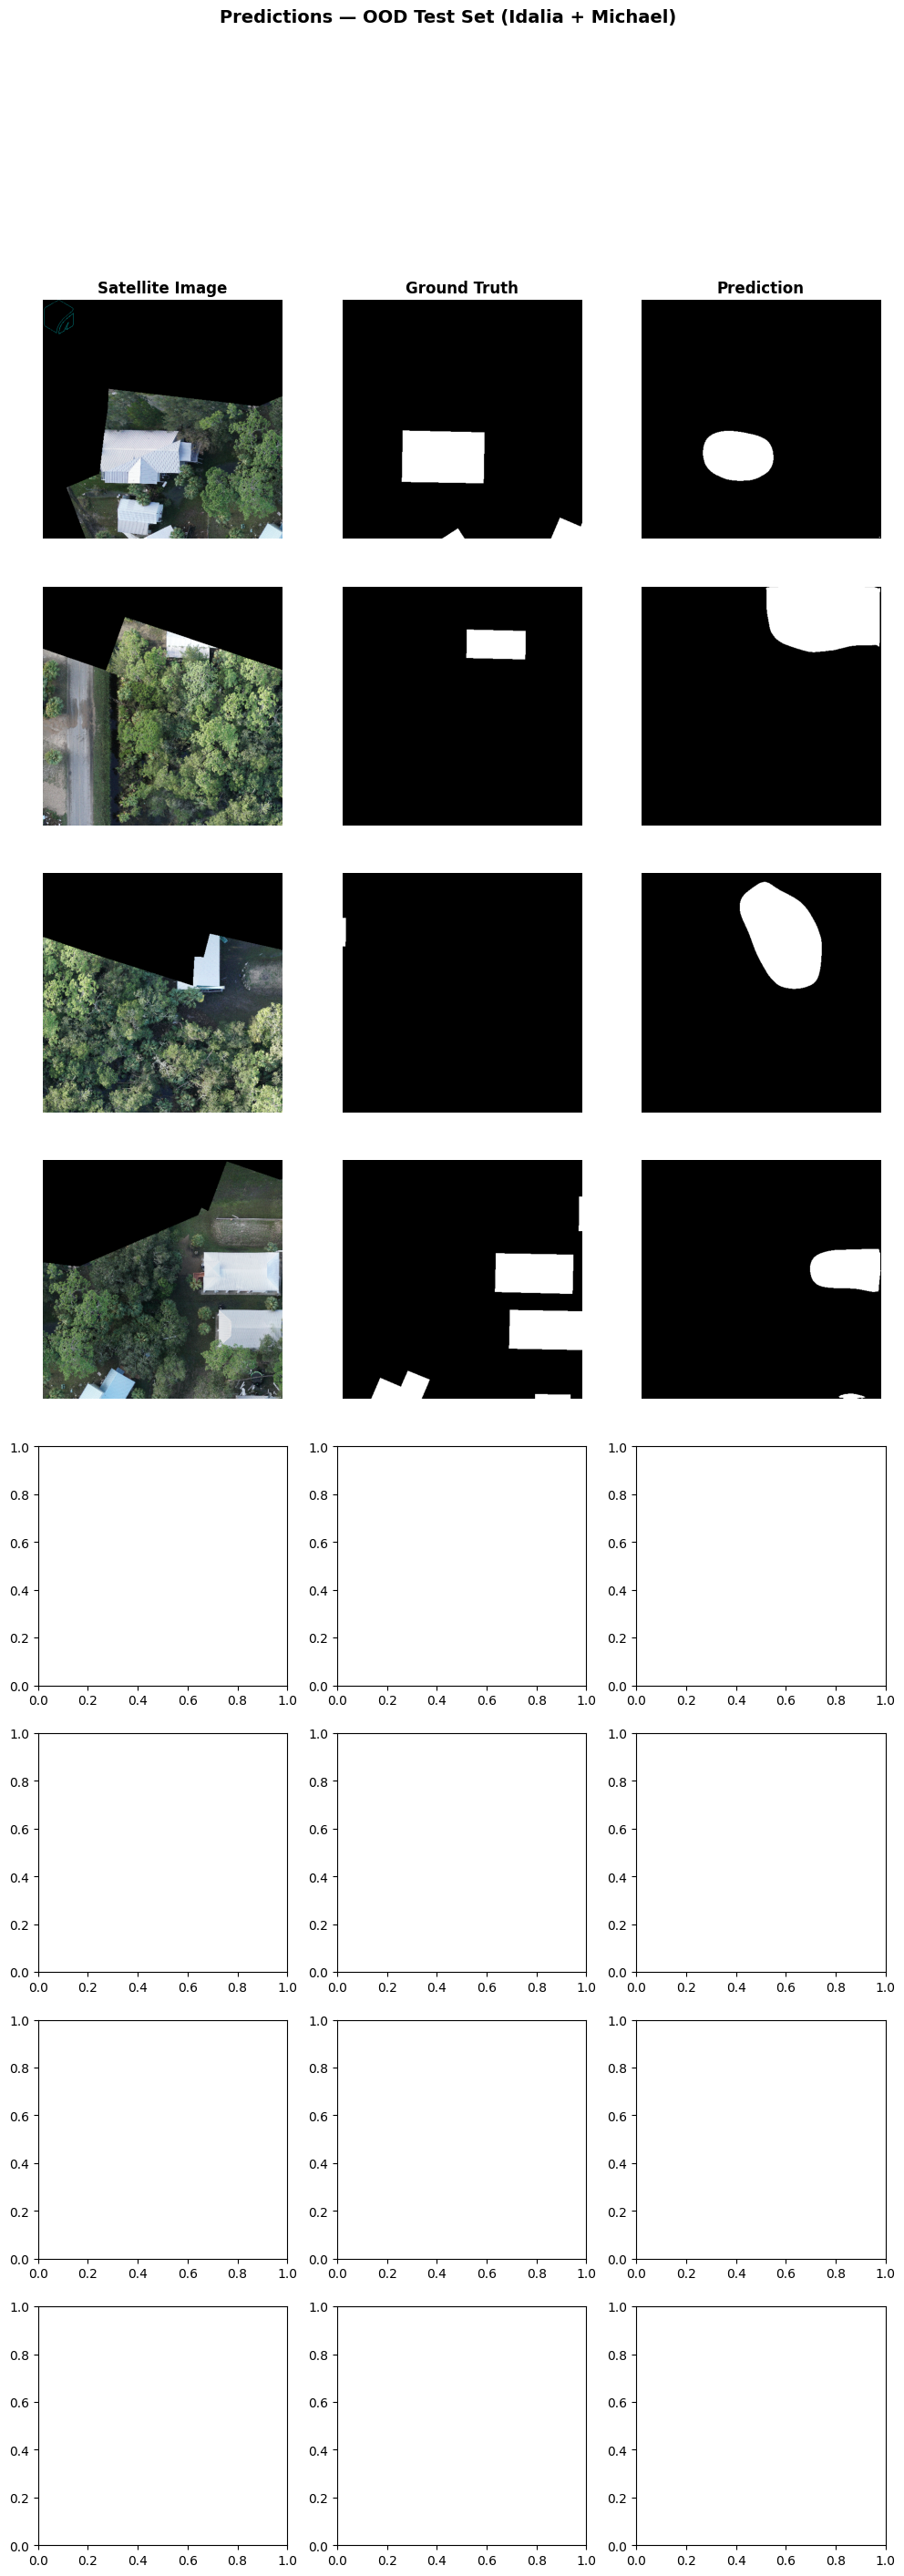

In [6]:
# ============================================================
# STEP 6: INFERENCE + VISUALISATION — 10/10
# ============================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from tqdm import tqdm

# -------------------------------------------------------
# 1. LOAD BEST CHECKPOINT
# -------------------------------------------------------
CHECKPOINT_DIR = os.path.expanduser("~/Downloads/disaster_checkpoints")
SAVE_PATH      = os.path.join(CHECKPOINT_DIR, "best_building_model.pth")

checkpoint = torch.load(SAVE_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state"])
model.eval()

print(f"✅ Loaded checkpoint from epoch {checkpoint['epoch']}")
print(f"   Best Val IoU : {checkpoint['best_iou']:.4f}")

# -------------------------------------------------------
# 2. FULL TEST SET EVALUATION
# -------------------------------------------------------
print(f"\n📊 Running full evaluation on {len(test_loader)} test batches...")

all_iou = []
all_f1  = []

with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc="Evaluating", leave=False):
        imgs  = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        logits = model(imgs)

        preds = (torch.sigmoid(logits) > 0.5).float()

        for pred, mask in zip(preds, masks):
            tp = (pred * mask).sum().item()
            fp = (pred * (1 - mask)).sum().item()
            fn = ((1 - pred) * mask).sum().item()
            iou = tp / (tp + fp + fn + 1e-7)
            f1  = (2 * tp) / (2 * tp + fp + fn + 1e-7)
            all_iou.append(iou)
            all_f1.append(f1)

mean_iou = np.mean(all_iou)
mean_f1  = np.mean(all_f1)
std_iou  = np.std(all_iou)

print(f"\n✅ Final Test Results (Idalia + Michael — OOD)")
print(f"   Mean IoU : {mean_iou:.4f} ± {std_iou:.4f}")
print(f"   Mean F1  : {mean_f1:.4f}")

# -------------------------------------------------------
# 3. TRAINING HISTORY PLOT
# -------------------------------------------------------
history = checkpoint["history"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training History — MiT-B3 + UNet", fontsize=14, fontweight="bold")

# Loss
axes[0].plot(history["train_loss"], color="#E8593C", linewidth=2, label="Train Loss")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# IoU
axes[1].plot(history["train_iou"], color="#3B8BD4", linewidth=2, label="Train IoU")
axes[1].plot(
    [i for i, v in enumerate(history["val_iou"]) if v > 0],
    [v for v in history["val_iou"] if v > 0],
    color="#1D9E75", linewidth=2, linestyle="--", label="Val IoU", marker="o"
)
axes[1].set_title("IoU Score")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("IoU")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning Rate
axes[2].plot(history["lr"], color="#EF9F27", linewidth=2)
axes[2].set_title("Learning Rate Schedule")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("LR")
axes[2].set_yscale("log")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "training_history.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"📊 History plot saved to Downloads/disaster_checkpoints/")

# -------------------------------------------------------
# 4. QUALITATIVE VISUALISATION — 8 random test tiles
# -------------------------------------------------------
print("\n🖼️  Generating qualitative predictions...")

# Grab a batch from test loader
test_iter        = iter(test_loader)
vis_imgs, vis_masks = next(test_iter)
vis_imgs  = vis_imgs[:8]
vis_masks = vis_masks[:8]

with torch.no_grad():
    vis_logits = model(vis_imgs.to(device))
    vis_preds  = (torch.sigmoid(vis_logits) > 0.5).float().cpu()

# Denormalise images for display
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

def denorm(tensor):
    img = tensor.permute(1, 2, 0).numpy()
    img = (img * std + mean)
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(8, 3, figsize=(12, 32))
fig.suptitle("Predictions — OOD Test Set (Idalia + Michael)", fontsize=14, fontweight="bold")

col_titles = ["Satellite Image", "Ground Truth", "Prediction"]
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=12, fontweight="bold")

for i in range(8):
    img  = denorm(vis_imgs[i])
    gt   = vis_masks[i].squeeze().numpy()
    pred = vis_preds[i].squeeze().numpy()

    # Compute per-tile IoU for title
    tp  = (pred * gt).sum()
    fp  = (pred * (1 - gt)).sum()
    fn  = ((1 - pred) * gt).sum()
    iou = tp / (tp + fp + fn + 1e-7)

    axes[i][0].imshow(img)
    axes[i][0].set_ylabel(f"IoU: {iou:.3f}", fontsize=10)
    axes[i][0].axis("off")

    axes[i][1].imshow(gt,   cmap="gray", vmin=0, vmax=1)
    axes[i][1].axis("off")

    axes[i][2].imshow(pred, cmap="gray", vmin=0, vmax=1)
    axes[i][2].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "predictions.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"🖼️  Predictions plot saved to Downloads/disaster_checkpoints/")

# -------------------------------------------------------
# 5. OVERLAY VISUALISATION — prediction on top of image
# -------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Prediction Overlay — Green=TP  Red=FP  Blue=FN", fontsize=13, fontweight="bold")
axes = axes.flatten()

for i in range(8):
    img  = denorm(vis_imgs[i])
    gt   = vis_masks[i].squeeze().numpy()
    pred = vis_preds[i].squeeze().numpy()

    # Build RGB overlay
    overlay = img.copy()
    tp_mask = (pred == 1) & (gt == 1)   # True Positive  → green
    fp_mask = (pred == 1) & (gt == 0)   # False Positive → red
    fn_mask = (pred == 0) & (gt == 1)   # False Negative → blue

    overlay[tp_mask] = [0.0, 0.8, 0.0]
    overlay[fp_mask] = [0.8, 0.0, 0.0]
    overlay[fn_mask] = [0.0, 0.0, 0.8]

    tp  = tp_mask.sum()
    fp  = fp_mask.sum()
    fn  = fn_mask.sum()
    iou = tp / (tp + fp + fn + 1e-7)

    axes[i].imshow(overlay)
    axes[i].set_title(f"IoU: {iou:.3f}", fontsize=11)
    axes[i].axis("off")

# Legend
legend_items = [
    mpatches.Patch(color=(0.0, 0.8, 0.0), label="True Positive"),
    mpatches.Patch(color=(0.8, 0.0, 0.0), label="False Positive"),
    mpatches.Patch(color=(0.0, 0.0, 0.8), label="False Negative"),
]
fig.legend(handles=legend_items, loc="lower center", ncol=3,
           fontsize=11, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "overlay.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"🖼️  Overlay plot saved to Downloads/disaster_checkpoints/")

# -------------------------------------------------------
# 6. FINAL REPORT
# -------------------------------------------------------
print(f"\n{'='*60}")
print(f"📋 FINAL REPORT")
print(f"   Model        : UNet + MiT-B3 encoder")
print(f"   Test set     : Idalia + Michael (OOD)")
print(f"   Mean IoU     : {mean_iou:.4f} ± {std_iou:.4f}")
print(f"   Mean F1      : {mean_f1:.4f}")
print(f"   Best Val IoU : {checkpoint['best_iou']:.4f}")
print(f"   Epochs run   : {checkpoint['epoch']}")
print(f"   Outputs      : {os.path.abspath(CHECKPOINT_DIR)}")
print(f"{'='*60}")

In [2]:
import os

BASE_DIR = "../../Building_Damage_Project"
OUT_DIR  = os.path.join(BASE_DIR, "train_data")
IMG_DIR  = os.path.join(OUT_DIR, "images")

all_files   = [f for f in os.listdir(IMG_DIR) if f.endswith(".npz")]
train_files = [f for f in all_files if f.startswith("train_")]
test_files  = [f for f in all_files if f.startswith("test_")]

# Extract unique storm names
def get_storms(files):
    storms = {}
    for f in files:
        # Remove split prefix and tile coords
        name = f.replace("train_", "", 1).replace("test_", "", 1)
        name = name.split("_y")[0]
        storms[name] = storms.get(name, 0) + 1
    return storms

train_storms = get_storms(train_files)
test_storms  = get_storms(test_files)

print(f"📊 TOTAL — Train: {len(train_files)} tiles | Test: {len(test_files)} tiles")

print(f"\n🟦 TRAIN STORMS ({len(train_storms)} unique):")
print(f"{'Storm':<35} {'Tiles':>8}")
print("-" * 45)
for storm, count in sorted(train_storms.items()):
    print(f"  {storm:<33} {count:>8}")

print(f"\n🟥 TEST STORMS ({len(test_storms)} unique):")
print(f"{'Storm':<35} {'Tiles':>8}")
print("-" * 45)
for storm, count in sorted(test_storms.items()):
    print(f"  {storm:<33} {count:>8}")

📊 TOTAL — Train: 95006 tiles | Test: 28491 tiles

🟦 TRAIN STORMS (46 unique):
Storm                                  Tiles
---------------------------------------------
  1001-Ian-01                           6361
  1001-Ian-02                           5445
  1001-Ian-03                           1872
  1001-Ian-04                           4343
  1001-Ian-05                           3773
  1001-Ian-06                           2238
  1001-Ian-07                           4144
  1001-Ian-08                            894
  1001-Ian-09                           4356
  1001-Ian-10                           1693
  1001-Ian-11                           5183
  1002-Ian-01                           6812
  1002-Ian-02                            674
  1002-Ian-03                            954
  1002-Ian-04                           2106
  1002-Ian-05                           1657
  1002-Ian-06                            804
  1002-Ian-07                           3973
  1002-Ian-08        

In [3]:
# Check for duplicate storm coverage
duplicates = [s for s in train_storms.keys() if s.startswith("_")]
originals  = [s.lstrip("_") for s in duplicates]

print("⚠️  Potential duplicate storms:")
for dup, orig in zip(duplicates, originals):
    dup_count  = train_storms.get(dup, 0)
    orig_count = train_storms.get(orig, 0)
    print(f"   {dup:<25} {dup_count:>6} tiles  ←→  "
          f"{orig:<25} {orig_count:>6} tiles")

print(f"\n💡 If these cover the same geography, "
      f"remove the _ prefixed versions before retraining.")

⚠️  Potential duplicate storms:
   _1002-Ian-08                1492 tiles  ←→  1002-Ian-08                 4445 tiles
   _1001-Ian-03                1826 tiles  ←→  1001-Ian-03                 1872 tiles
   _1002-Ian-10                1350 tiles  ←→  1002-Ian-10                 1353 tiles
   _eruption-03                 376 tiles  ←→  eruption-03                  378 tiles
   _1002-Ian-09                 781 tiles  ←→  1002-Ian-09                  784 tiles
   _Harvey-03                   207 tiles  ←→  Harvey-03                    206 tiles

💡 If these cover the same geography, remove the _ prefixed versions before retraining.


In [4]:
import os
import glob

IMG_DIR  = os.path.join(BASE_DIR, "train_data", "images")
MASK_DIR = os.path.join(BASE_DIR, "train_data", "masks")

# Find all tiles with _ prefix storms
dup_img_files  = [
    f for f in os.listdir(IMG_DIR)
    if f.endswith(".npz") and f.startswith("train__")
]

# Double check by looking for storm name starting with _
dup_img_files = []
for f in os.listdir(IMG_DIR):
    if not f.endswith(".npz"):
        continue
    # filename: train_{stormname}_y{y}_x{x}.npz
    storm_part = f.replace("train_", "", 1).split("_y")[0]
    if storm_part.startswith("_"):
        dup_img_files.append(f)

print(f"🔍 Found {len(dup_img_files)} duplicate tiles to remove...")

# Confirm before deleting
storms_found = set()
for f in dup_img_files:
    storm_part = f.replace("train_", "", 1).split("_y")[0]
    storms_found.add(storm_part)

print(f"   Storms being removed:")
for s in sorted(storms_found):
    count = len([f for f in dup_img_files if s in f])
    print(f"   {s:<30} {count} tiles")

print(f"\n⚠️  About to delete {len(dup_img_files)} image + "
      f"{len(dup_img_files)} mask files")
print(f"   Total tiles remaining after: "
      f"{len(os.listdir(IMG_DIR)) - len(dup_img_files)}")

🔍 Found 6032 duplicate tiles to remove...
   Storms being removed:
   _1001-Ian-03                   1826 tiles
   _1002-Ian-08                   1492 tiles
   _1002-Ian-09                   781 tiles
   _1002-Ian-10                   1350 tiles
   _Harvey-03                     207 tiles
   _eruption-03                   376 tiles

⚠️  About to delete 6032 image + 6032 mask files
   Total tiles remaining after: 192663


In [5]:
deleted = 0
failed  = []

for fname in dup_img_files:
    img_path  = os.path.join(IMG_DIR,  fname)
    mask_path = os.path.join(MASK_DIR, fname)

    try:
        if os.path.exists(img_path):
            os.remove(img_path)
        if os.path.exists(mask_path):
            os.remove(mask_path)
        deleted += 1
    except Exception as e:
        failed.append((fname, str(e)))

print(f"✅ Deleted {deleted} tile pairs")

if failed:
    print(f"⚠️  {len(failed)} failed:")
    for f, e in failed:
        print(f"   {f}: {e}")

# Verify final counts
remaining_train = [
    f for f in os.listdir(IMG_DIR)
    if f.endswith(".npz") and f.startswith("train_")
]
remaining_test = [
    f for f in os.listdir(IMG_DIR)
    if f.endswith(".npz") and f.startswith("test_")
]

print(f"\n📊 Final tile counts:")
print(f"   Train : {len(remaining_train)}")
print(f"   Test  : {len(remaining_test)}")
print(f"   Total : {len(remaining_train) + len(remaining_test)}")

✅ Deleted 6032 tile pairs

📊 Final tile counts:
   Train : 88974
   Test  : 28491
   Total : 117465


In [6]:
import os

BASE_DIR = "../../Building_Damage_Project"
OUT_DIR  = os.path.join(BASE_DIR, "train_data")
IMG_DIR  = os.path.join(OUT_DIR, "images")

all_files   = [f for f in os.listdir(IMG_DIR) if f.endswith(".npz")]
train_files = [f for f in all_files if f.startswith("train_")]
test_files  = [f for f in all_files if f.startswith("test_")]

# Extract unique storm names
def get_storms(files):
    storms = {}
    for f in files:
        # Remove split prefix and tile coords
        name = f.replace("train_", "", 1).replace("test_", "", 1)
        name = name.split("_y")[0]
        storms[name] = storms.get(name, 0) + 1
    return storms

train_storms = get_storms(train_files)
test_storms  = get_storms(test_files)

print(f"📊 TOTAL — Train: {len(train_files)} tiles | Test: {len(test_files)} tiles")

print(f"\n🟦 TRAIN STORMS ({len(train_storms)} unique):")
print(f"{'Storm':<35} {'Tiles':>8}")
print("-" * 45)
for storm, count in sorted(train_storms.items()):
    print(f"  {storm:<33} {count:>8}")

print(f"\n🟥 TEST STORMS ({len(test_storms)} unique):")
print(f"{'Storm':<35} {'Tiles':>8}")
print("-" * 45)
for storm, count in sorted(test_storms.items()):
    print(f"  {storm:<33} {count:>8}")

📊 TOTAL — Train: 88974 tiles | Test: 28491 tiles

🟦 TRAIN STORMS (40 unique):
Storm                                  Tiles
---------------------------------------------
  1001-Ian-01                           6361
  1001-Ian-02                           5445
  1001-Ian-03                           1872
  1001-Ian-04                           4343
  1001-Ian-05                           3773
  1001-Ian-06                           2238
  1001-Ian-07                           4144
  1001-Ian-08                            894
  1001-Ian-09                           4356
  1001-Ian-10                           1693
  1001-Ian-11                           5183
  1002-Ian-01                           6812
  1002-Ian-02                            674
  1002-Ian-03                            954
  1002-Ian-04                           2106
  1002-Ian-05                           1657
  1002-Ian-06                            804
  1002-Ian-07                           3973
  1002-Ian-08        

✅ Loaded model from epoch: 1
Best IoU stored: 0.5997840234481634


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].



📊 FINAL RESULTS (Epoch 1 Model)
Mean IoU : 0.5998
Mean F1  : 0.7220

🔍 Showing sample predictions...


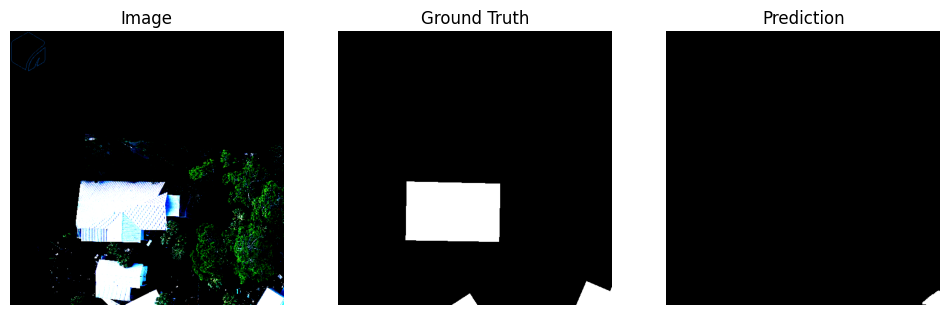

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


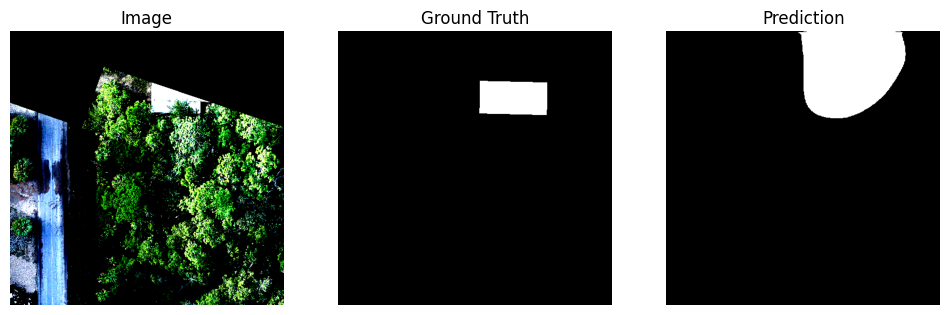

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


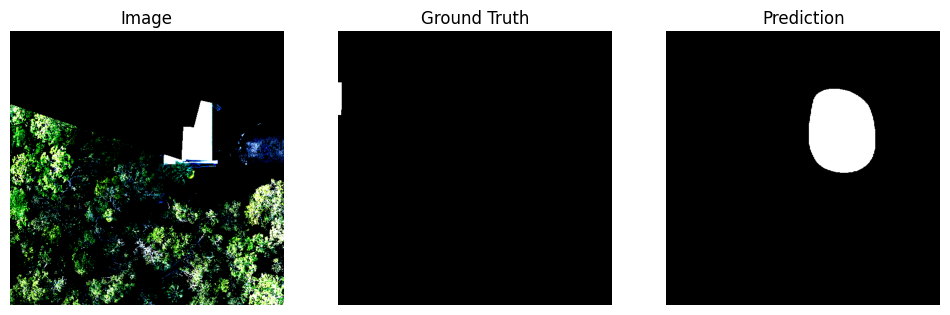

In [14]:
import torch
import matplotlib.pyplot as plt

# ================================
# LOAD MODEL
# ================================
checkpoint = torch.load(SAVE_PATH, map_location=device)

model.load_state_dict(checkpoint["model_state"])
model.to(device)
model.eval()

print("✅ Loaded model from epoch:", checkpoint["epoch"])
print("Best IoU stored:", checkpoint["best_iou"])


# ================================
# EVALUATION
# ================================
total_iou = 0.0
total_f1  = 0.0

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs  = imgs.to(device)
        masks = masks.to(device)

        logits = model(imgs)

        total_iou += compute_iou(logits, masks)
        total_f1  += compute_f1(logits, masks)

avg_iou = total_iou / len(test_loader)
avg_f1  = total_f1  / len(test_loader)

print("\n📊 FINAL RESULTS (Epoch 1 Model)")
print(f"Mean IoU : {avg_iou:.4f}")
print(f"Mean F1  : {avg_f1:.4f}")


# ================================
# VISUALIZATION
# ================================
model.eval()

imgs, masks = next(iter(test_loader))

imgs  = imgs.to(device)
masks = masks.to(device)

with torch.no_grad():
    logits = model(imgs)
    preds = (torch.sigmoid(logits) > 0.5).float()

imgs  = imgs.cpu()
masks = masks.cpu()
preds = preds.cpu()

print("\n🔍 Showing sample predictions...")

for i in range(min(3, imgs.size(0))):
    plt.figure(figsize=(12,4))

    # Image
    plt.subplot(1,3,1)
    plt.imshow(imgs[i].permute(1,2,0))
    plt.title("Image")
    plt.axis("off")

    # Ground Truth
    plt.subplot(1,3,2)
    plt.imshow(masks[i][0], cmap='gray')
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(1,3,3)
    plt.imshow(preds[i][0], cmap='gray')
    plt.title("Prediction")
    plt.axis("off")

    plt.show()